In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from google.colab import files

uploaded = files.upload()

Saving train (2).csv to train (2).csv


In [3]:
df = pd.read_csv('train (2).csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
print(f"Пропущенных значений в колонке Cabin: {df['Cabin'].isna().sum()/df['PassengerId'].count() * 100:.0f}%")

Пропущенных значений в колонке Cabin: 77%


In [9]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [10]:
df['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


### 1. Подготовка датасета


Уберем колонку `Ticket`, т.к. почти все значения в ней уникальны, и смысла для модели номер билета не имеет (аналогично с `Name`, `PassengerId`).

Т.к. в колонке `Cabin` 77% процентов пропусков, и есть много разных вариантов названий кают, удалим изначальную версию колонки и добавим новую колонку `hasCabin`, которая будет показывать, есть у человека каюта или нет. Заполним пропуски в колонке `Age` медианой, чтобы не терять этих людей. Также заполним два пропуска в `Embarked` самым популярным значением.

In [18]:
clear_df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])
clear_df['HasCabin'] = df['Cabin'].notna().astype(int)
clear_df['Age'] = clear_df['Age'].fillna(clear_df['Age'].median())
clear_df['Embarked'] = clear_df['Embarked'].fillna(clear_df['Embarked'].mode()[0])

In [19]:
clear_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,28.0,1,2,23.4500,S,0
889,1,1,male,26.0,0,0,30.0000,C,1


Колонки `Sex` и `Embarked` переведем в категории с помощью one-hot-encoding, т.к. в них 2-3 уникальных типа.

In [20]:
clear_df = pd.get_dummies(clear_df, columns=['Sex', 'Embarked'], drop_first=True)

### 2. Разбиение на train, test

In [28]:
Y = clear_df['Survived']
X = clear_df.drop(columns=['Survived'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2026, stratify=Y)

Проверка мультиколлинеарности: не убираем никакие факторы, т.к. порог обычно берется за 0.8 и выше.

In [29]:
corrs = X_train.corr()
upper_tri = corrs.where(np.triu(np.ones(corrs.shape), k=1).astype(np.bool))
upper_tri

,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S
Pclass,NaN,-0.332275,0.058488,0.022898,-0.537853,-0.735523,0.118791,0.229363,0.059646
Age,NaN,NaN,-0.210556,-0.151684,0.086925,0.228222,0.090613,-0.037439,0.000746
SibSp,NaN,NaN,NaN,0.399642,0.165378,-0.011024,-0.157190,-0.030288,0.069961
Parch,NaN,NaN,NaN,NaN,0.209858,0.042318,-0.264338,-0.081479,0.053547
Fare,NaN,NaN,NaN,NaN,NaN,0.475269,-0.174439,-0.118926,-0.164191
HasCabin,NaN,NaN,NaN,NaN,NaN,NaN,-0.142064,-0.146226,-0.103901
Sex_male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.065425,0.142267
Embarked_Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.510920
Embarked_S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


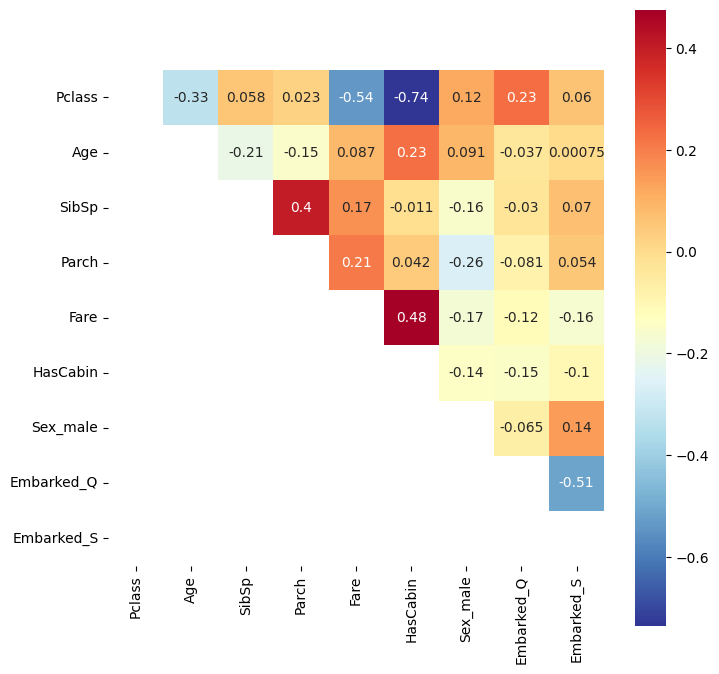

In [30]:
plt.figure(figsize=(8, 8))
sns.heatmap(upper_tri, cmap="RdYlBu_r", square=True, annot=True);

### 3. Baseline-model

В качестве тривиальной модели возьмем модель, которая предсказывает принадлежность к классу `Survived` на основе эмпирической вероятности (т.е. 38%, что случайный человек выжил).

In [37]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified", random_state=2026)
dummy_clf.fit(X_train, Y_train);

Проверим качество бейзлайн-модели:

Метрика для измерения качества: `f1-score`, т.к. `accuracy` не подходит из-за того, что baseline-модель (всегда говорящая `Survived = 0`) уже дает `accuracy = 62%`. F1 т.к. нам одинаково важны и false positive, и false negative.

In [38]:
from sklearn.metrics import f1_score

Y_dummy_pred = dummy_clf.predict(X_test)
base_f1_score = f1_score(Y_test, Y_dummy_pred)
base_f1_score

0.5205479452054794

### 4. ML-модель

Выбрана логистическая регрессия, т.к. задача - бинарная классификация. Также заранее применим стандартизацию для сходимости модели.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

log_reg = LogisticRegression()

cross_val_score(log_reg, X_train_scaled, Y_train, cv=5, scoring='f1')

array([0.64761905, 0.67924528, 0.78181818, 0.75      , 0.74766355])

In [48]:
log_reg.fit(X_train_scaled, Y_train);
X_test_scaled = scaler.transform(X_test)
f1_score(Y_test, log_reg.predict(X_test_scaled))

0.7391304347826086

In [47]:
for C in [0.01, 0.1, 1, 10, 100]:
    log_reg = LogisticRegression(penalty='l2', C=C, max_iter=1000, random_state=42)
    scores = cross_val_score(log_reg, X_train_scaled, Y_train, cv=5, scoring='f1')
    print(f"C={C:6.2f}: mean={scores.mean():.4f}, std={scores.std():.4f}, разброс={scores.max()-scores.min():.4f}")

C=  0.01: mean=0.6922, std=0.0888, разброс=0.2646
C=  0.10: mean=0.7201, std=0.0528, разброс=0.1532
C=  1.00: mean=0.7213, std=0.0498, разброс=0.1342
C= 10.00: mean=0.7199, std=0.0481, разброс=0.1272
C=100.00: mean=0.7199, std=0.0481, разброс=0.1272


In [59]:
log_reg = LogisticRegression(C=0.1) # лучший результат: f1 = 0.74
log_reg.fit(X_train_scaled, Y_train);
X_test_scaled = scaler.transform(X_test)
f1_score(Y_test, log_reg.predict(X_test_scaled))

0.7445255474452555